# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Load data

In [2]:
processor = DataProcessor()
data = processor.get_optimization_data()

### Load model

In [3]:
# Create Smooth Model instance
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})


### Projected GD

In [4]:

# Compute Lipschitz constant for step size
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientMethod = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientMethod.keys())
print(f"Converged: {result_ProjectedGradientMethod['converged']}")
print(f"Iterations: {result_ProjectedGradientMethod['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 336


#### Analyse convergence Projected gradient descent

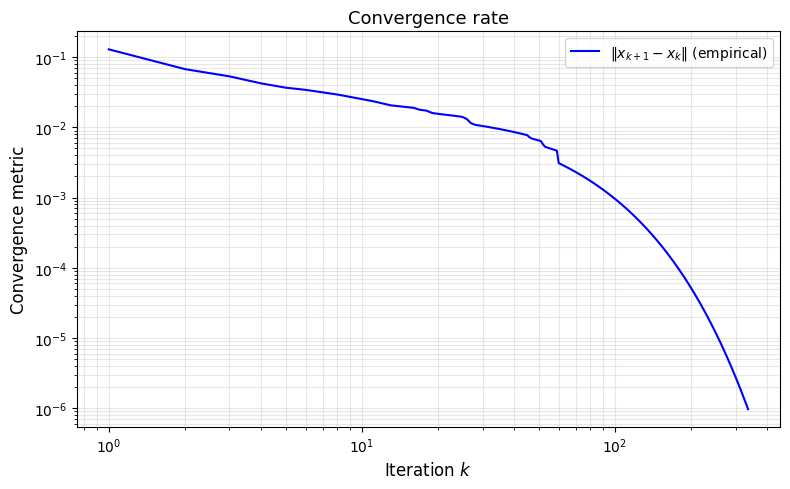

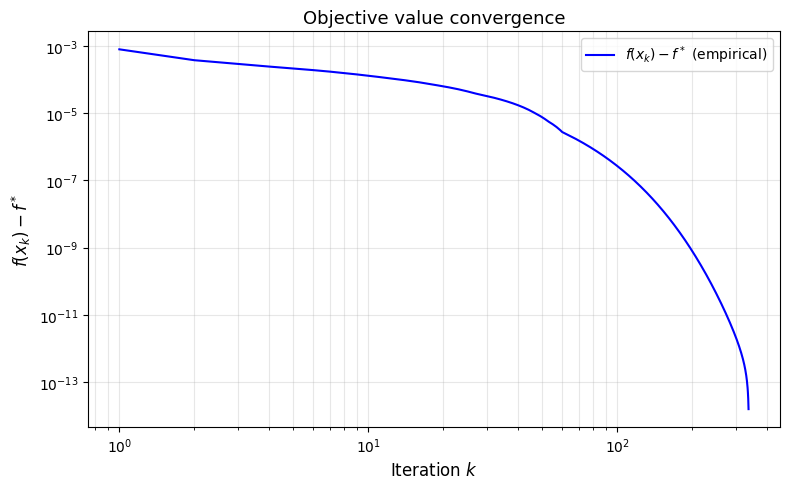

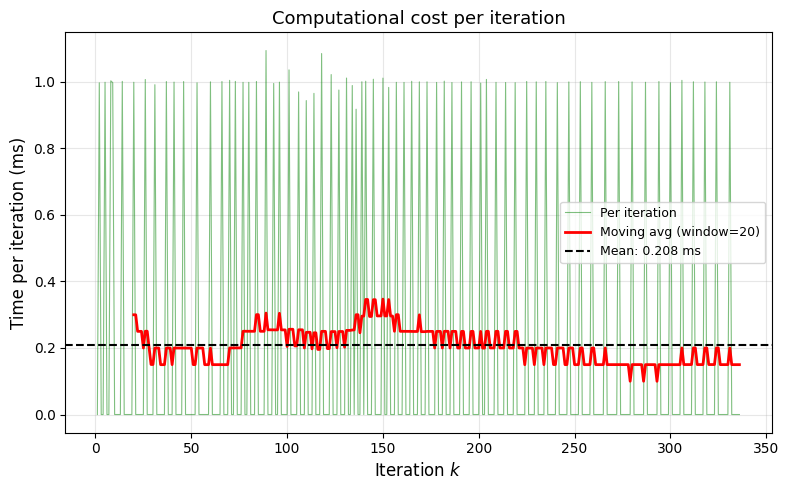

Total time: 0.0700 seconds
Total iterations: 336
Final objective value: -0.001049
Average time per iteration: 0.2083 ms
Std time per iteration: 0.4062 ms


In [5]:
# Plot convergence in iteration 


plot_convergence(result_ProjectedGradientMethod, theoretical_rate_exp=-0.5, rate_label=r'$O(k^{-1/2})$')

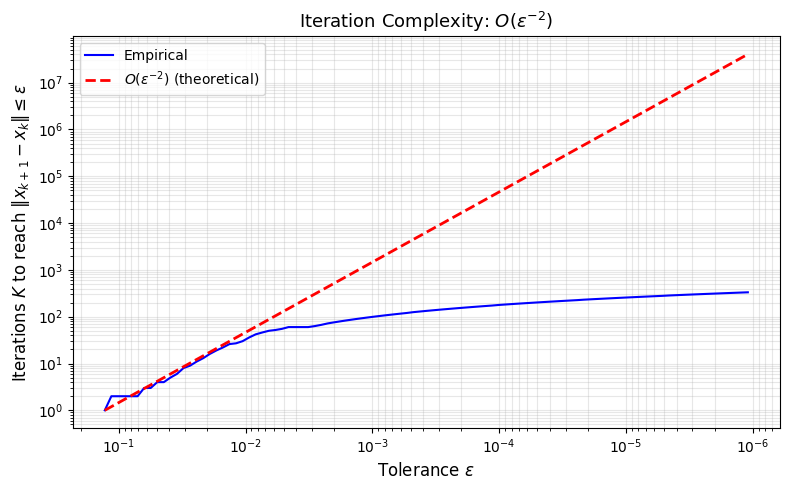

In [ ]:
plot_iterations_vs_tolerance(result_ProjectedGradientMethod, theoretical_exp=2, rate_label=r'$O(\epsilon^{-2})$')

#### Analyse with different stepsize

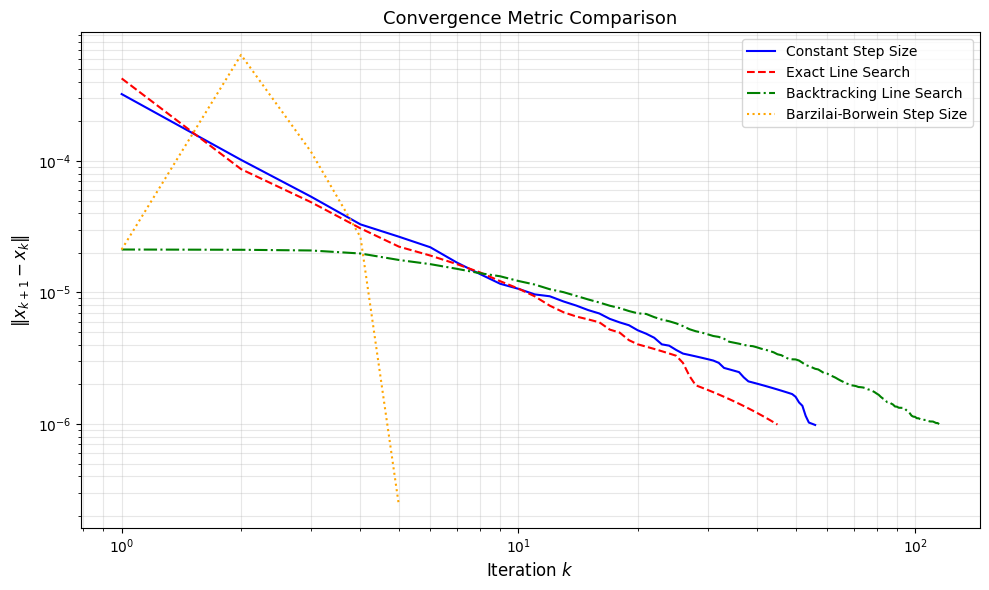

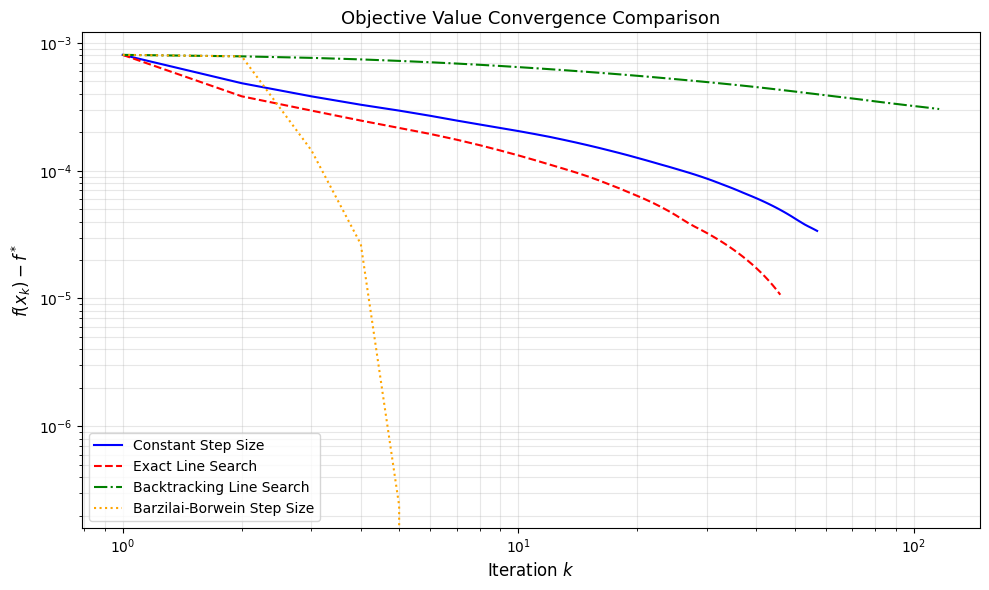

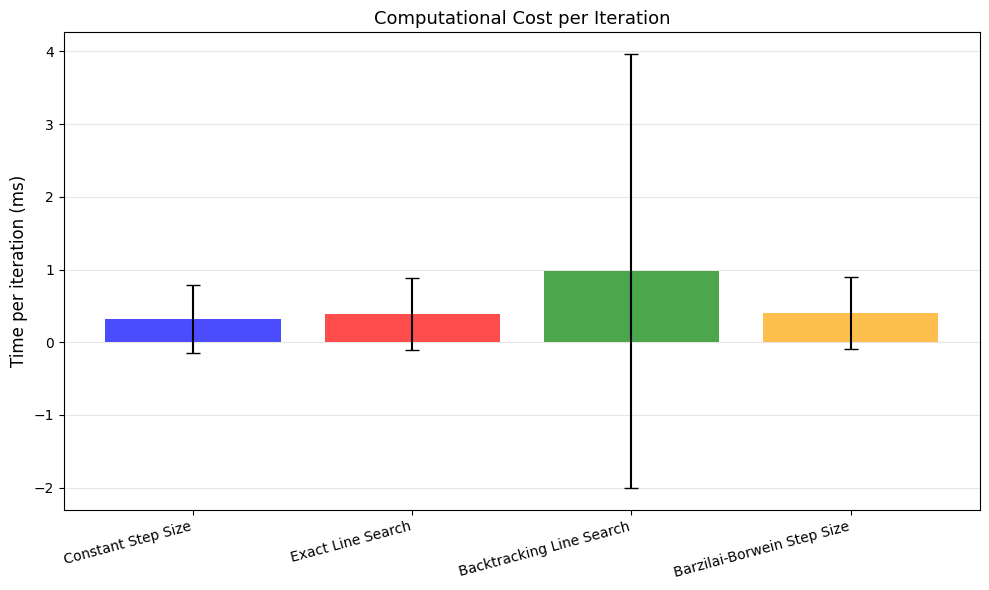

In [28]:
method1 = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
}, ValuePerformanceIndicator())
method1_result = method1.optimize(model, w0)
method2 = ProjectedGradientMethod({
    'step_size': 1.0 / L,
    'max_iter': 1000,
}, ValuePerformanceIndicator())

method2_result = method2.optimize(model, w0)    

method3 =  ProjectedGradientMethod({
        'step_size': BacktrackingLineSearch(),
    'max_iter': 1000,
}, ValuePerformanceIndicator())
method3_result = method3.optimize(model, w0)

method4 = ProjectedGradientMethod({
    'step_size': BarzilaiBorweinStepSize('BB1'),
    'max_iter': 1000,
}, ValuePerformanceIndicator())
method4_result = method4.optimize(model, w0)

methods = {"Constant Step Size": method2_result,
           "Exact Line Search": method1_result,
           "Backtracking Line Search": method3_result,
           "Barzilai-Borwein Step Size": method4_result}
compare_methods(methods)

### Projected gradient with momentum

In [7]:

L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-6,
    'momentum':0.9,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 144


#### Analyse convergence Projected gradient with momentum

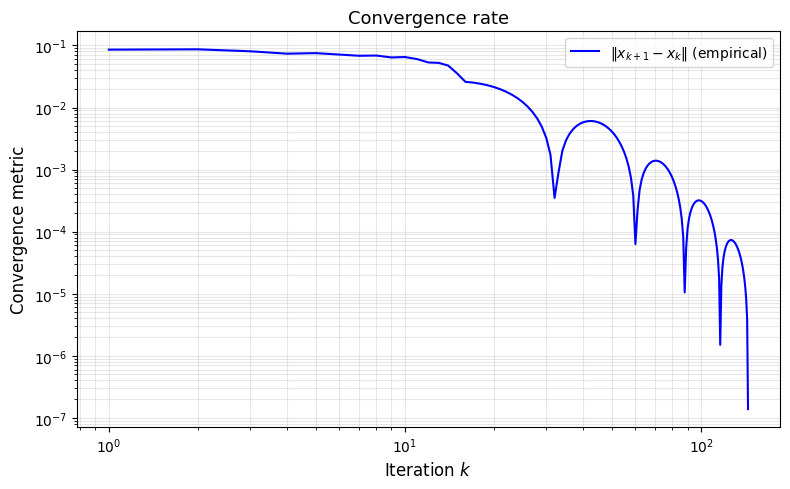

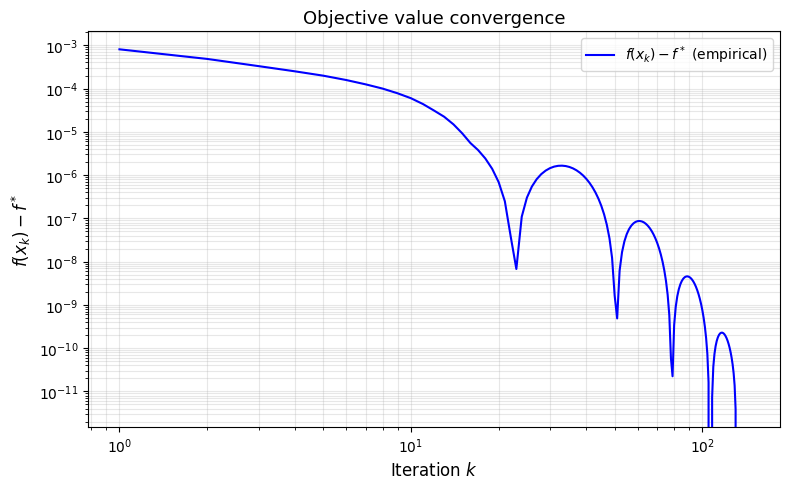

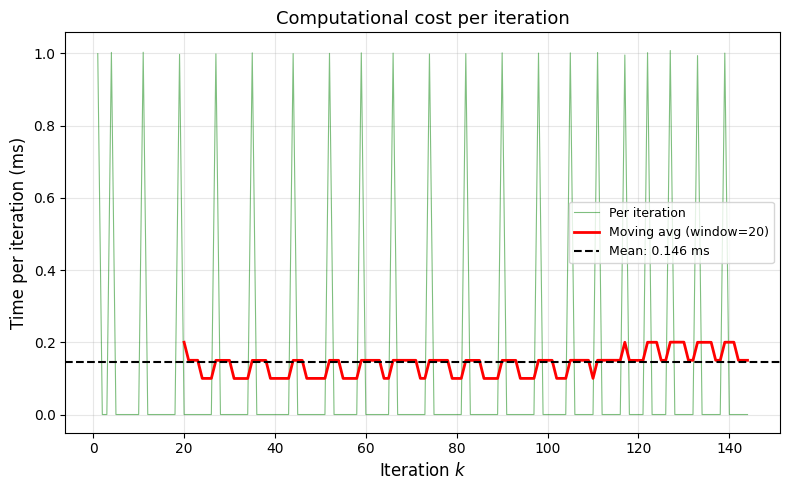

Total time: 0.0210 seconds
Total iterations: 144
Final objective value: -0.001049
Average time per iteration: 0.1458 ms
Std time per iteration: 0.3530 ms


In [8]:
plot_convergence(result_ProjectedGradientDescentMomentum)

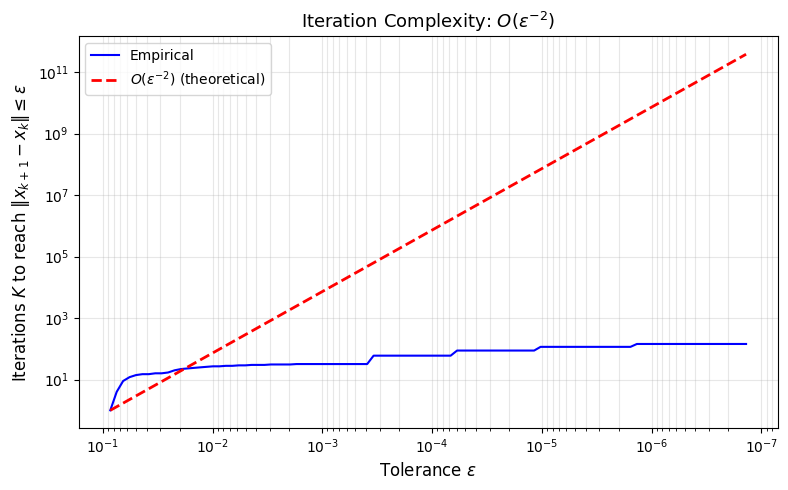

In [9]:
plot_iterations_vs_tolerance(result_ProjectedGradientDescentMomentum, theoretical_exp=2, rate_label=r'$O(\epsilon^{-2})$')

#### Projected Randomized Coordinate Descent

In [10]:
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-6,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedRandomizedCoordinateDescent = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedRandomizedCoordinateDescent.keys())
print(f"Converged: {result_ProjectedRandomizedCoordinateDescent['converged']}")
print(f"Iterations: {result_ProjectedRandomizedCoordinateDescent['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 157


#### Analyse convergence GradientDescentRandomized

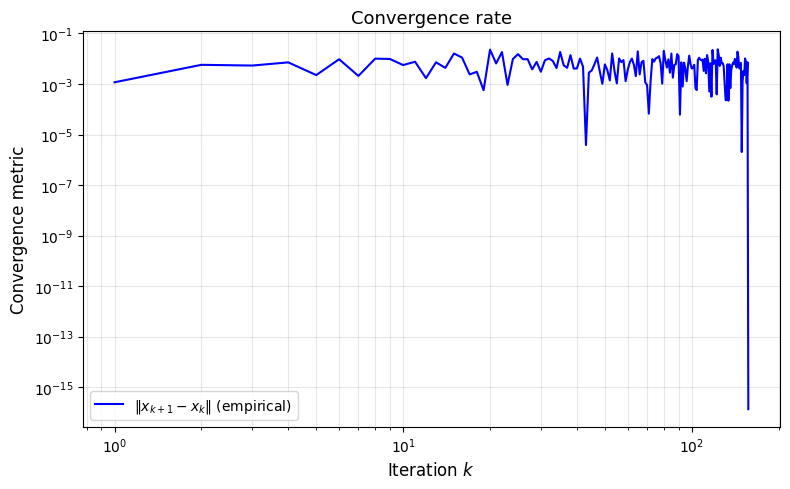

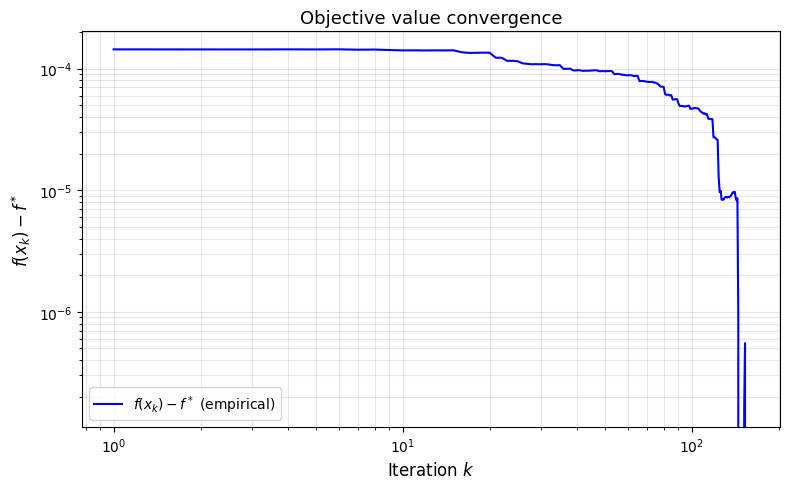

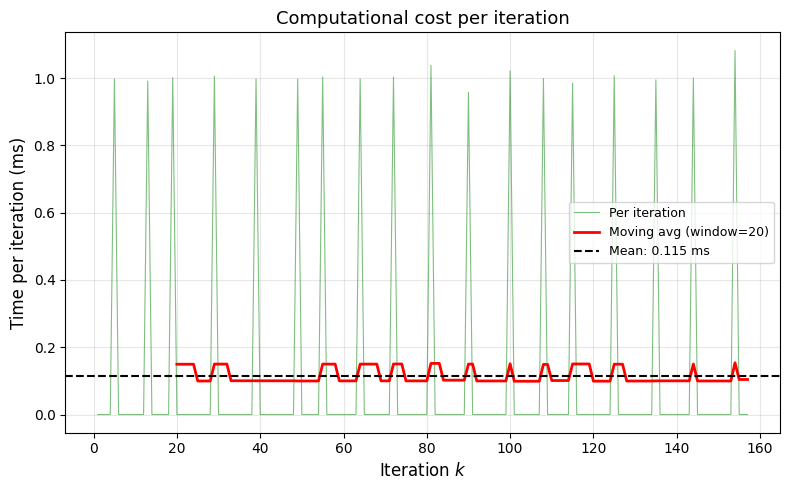

Total time: 0.0181 seconds
Total iterations: 157
Final objective value: -0.000386
Average time per iteration: 0.1151 ms
Std time per iteration: 0.3200 ms


In [11]:
plot_convergence(result_ProjectedRandomizedCoordinateDescent)

#### Further analysis on Randomized coordinate descent

In [29]:
# Run Randomized Coordinate Descent multiple times to analyze convergence variance
n_runs = 20
max_iter = 1000

# Storage for results
all_metrics = []
all_obj_values = []
all_iterations = []

for run in range(n_runs):
    method_run = ProjectedRandomizedCoordinateDescent({
        'step_size': 1.0 / L,
        'max_iter': max_iter,
        'tol': 1e-12,  # Very small to ensure we run all iterations
    }, IteratePerformanceIndicator())
    
    result = method_run.optimize(model, w0)
    all_metrics.append(result['metric'])
    all_obj_values.append(result['obj_value'])
    all_iterations.append(result['iterations'])

print(f"Completed {n_runs} runs")
print(f"Iterations: min={min(all_iterations)}, max={max(all_iterations)}, mean={np.mean(all_iterations):.1f}")

Completed 20 runs
Iterations: min=137, max=179, mean=150.2


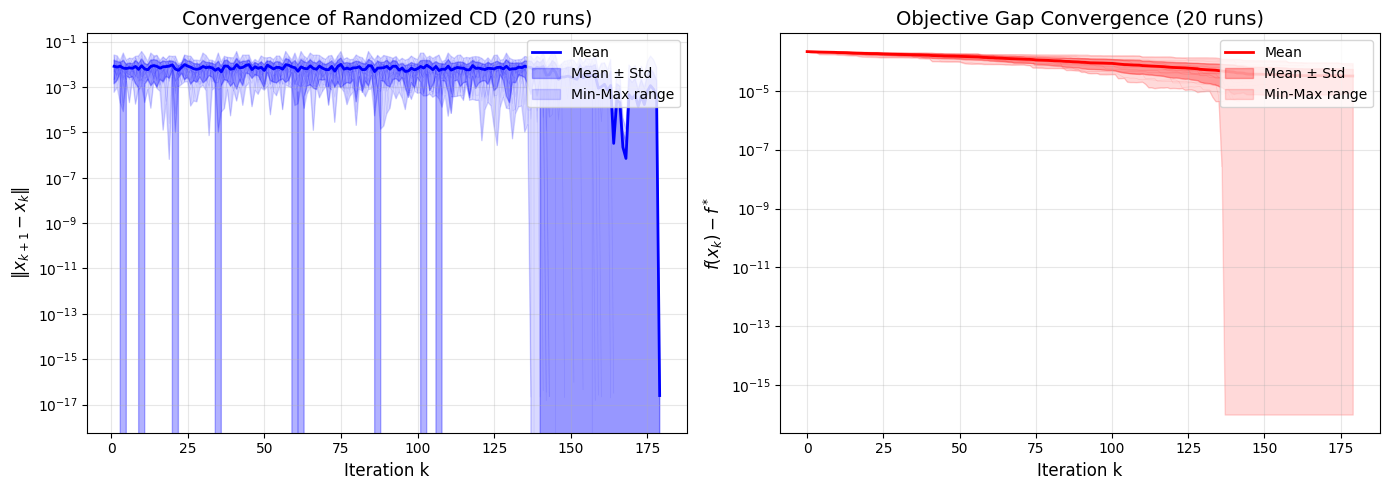


Final statistics after 1000 iterations:
  ||x_k+1 - x_k||: mean=2.48e-17, std=2.12e-17
  f(x_k) - f*:     mean=3.18e-05, std=2.33e-05
  f* estimate:     -0.000457


In [ ]:
# Plot convergence zones for Randomized Coordinate Descent

# Pad arrays to same length (some runs may converge earlier)
max_len = max(len(m) for m in all_metrics)
metrics_padded = np.array([np.pad(m, (0, max_len - len(m)), mode='edge') for m in all_metrics])
obj_padded = np.array([np.pad(o, (0, max_len + 1 - len(o)), mode='edge') for o in all_obj_values])

# Compute statistics
metrics_mean = np.mean(metrics_padded, axis=0)
metrics_std = np.std(metrics_padded, axis=0)
metrics_min = np.min(metrics_padded, axis=0)
metrics_max = np.max(metrics_padded, axis=0)

obj_mean = np.mean(obj_padded, axis=0)
obj_std = np.std(obj_padded, axis=0)
obj_min = np.min(obj_padded, axis=0)
obj_max = np.max(obj_padded, axis=0)

f_star = np.min([o[-1] for o in all_obj_values])
obj_gap_padded = obj_padded - f_star

obj_gap_mean = np.mean(obj_gap_padded, axis=0)
obj_gap_std = np.std(obj_gap_padded, axis=0)
obj_gap_min = np.min(obj_gap_padded, axis=0)
obj_gap_max = np.max(obj_gap_padded, axis=0)

iterations = np.arange(1, max_len + 1)
iterations_obj = np.arange(0, max_len + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.semilogy(iterations, metrics_mean, 'b-', linewidth=2, label='Mean')
ax1.fill_between(iterations, metrics_mean - metrics_std, metrics_mean + metrics_std, 
                  alpha=0.3, color='blue', label='Mean ± Std')
ax1.fill_between(iterations, metrics_min, metrics_max, 
                  alpha=0.15, color='blue', label='Min-Max range')

# Plot individual runs with transparency
for i, m in enumerate(all_metrics):
    ax1.semilogy(range(1, len(m)+1), m, 'b-', alpha=0.1, linewidth=0.5)

ax1.set_xlabel('Iteration k', fontsize=12)
ax1.set_ylabel(r'$\|x_{k+1} - x_k\|$', fontsize=12)
ax1.set_title(f'Convergence of Randomized CD ({n_runs} runs)', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
positive_mask = obj_gap_mean > 0
ax2.semilogy(iterations_obj[positive_mask], obj_gap_mean[positive_mask], 'r-', linewidth=2, label='Mean')
ax2.fill_between(iterations_obj, 
                  np.maximum(obj_gap_mean - obj_gap_std, 1e-16), 
                  obj_gap_mean + obj_gap_std, 
                  alpha=0.3, color='red', label='Mean ± Std')
ax2.fill_between(iterations_obj, 
                  np.maximum(obj_gap_min, 1e-16), 
                  obj_gap_max, 
                  alpha=0.15, color='red', label='Min-Max range')

for i, o in enumerate(all_obj_values):
    gap = np.array(o) - f_star
    positive = gap > 0
    iters = np.arange(len(o))
    ax2.semilogy(iters[positive], gap[positive], 'r-', alpha=0.1, linewidth=0.5)

ax2.set_xlabel('Iteration k', fontsize=12)
ax2.set_ylabel(r'$f(x_k) - f^*$', fontsize=12)
ax2.set_title(f'Objective Gap Convergence ({n_runs} runs)', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal statistics after {max_iter} iterations:")
print(f"  ||x_k+1 - x_k||: mean={metrics_mean[-1]:.2e}, std={metrics_std[-1]:.2e}")
print(f"  f(x_k) - f*:     mean={obj_gap_mean[-1]:.2e}, std={obj_gap_std[-1]:.2e}")
print(f"  f* estimate:     {f_star:.6f}")

#### Comparaison of the methods 

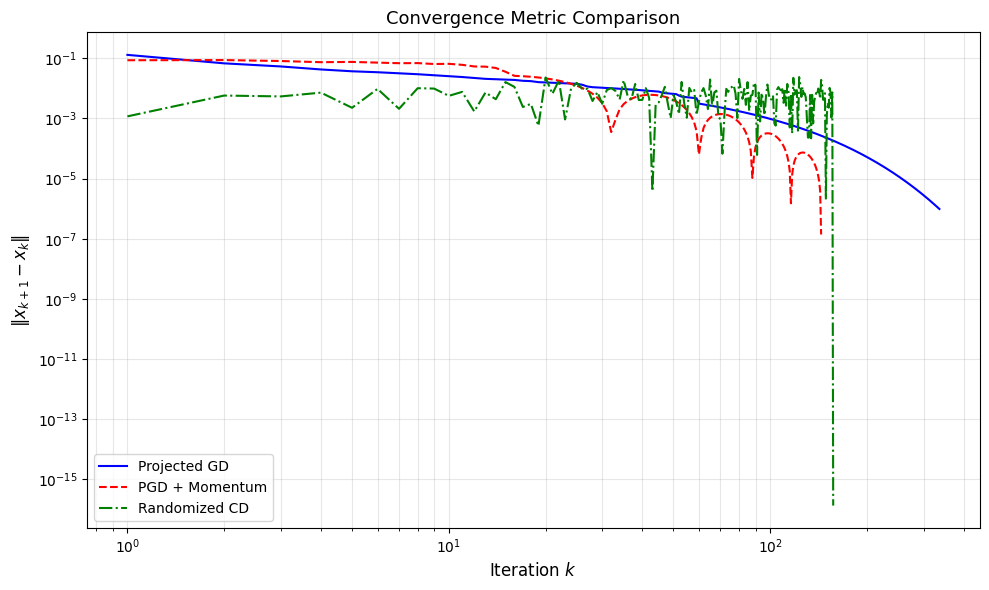

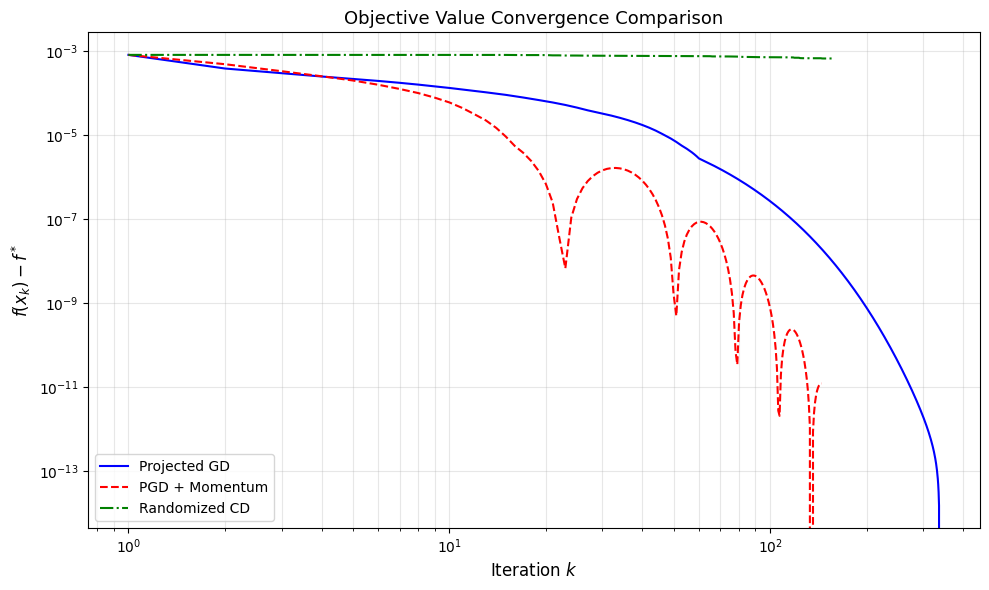

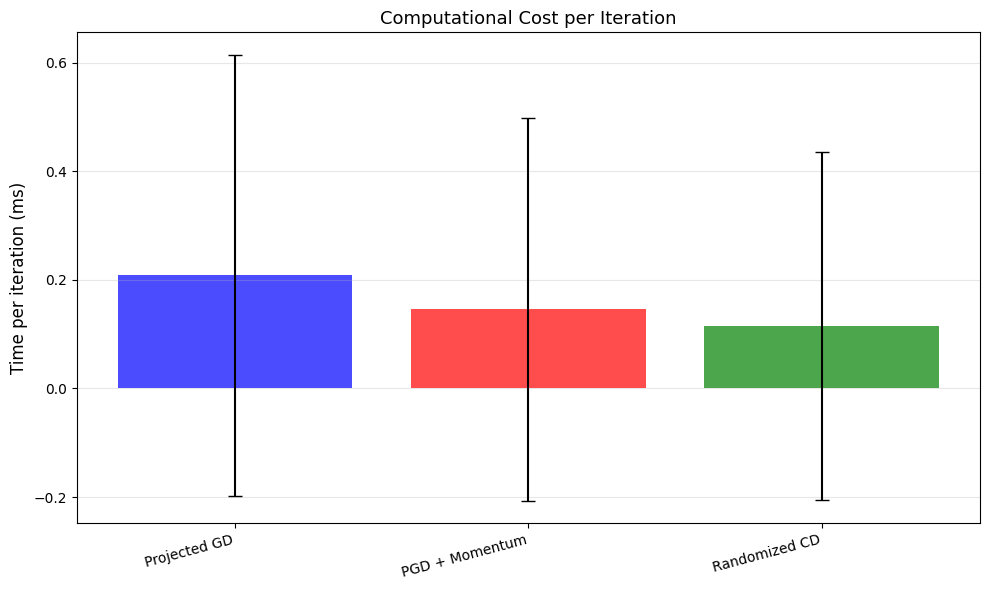

In [12]:
compare_methods({
    'Projected GD': result_ProjectedGradientMethod,
    'PGD + Momentum': result_ProjectedGradientDescentMomentum,
    'Randomized CD': result_ProjectedRandomizedCoordinateDescent,
})

#### Further analysis of the RandomizedCoordinateDescent 

### Non smooth model

In [13]:
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})


#### Projected Subgradient Method

#### Proximal Gradient Method

In [14]:
method = ProximalGradientMethod({
    

})

TypeError: ProximalGradientMethod.__init__() missing 1 required positional argument: 'performance_indicator'